# Coastal Sentinel-2 Pixel Classification

Interactive notebook version of the coastal habitat classifier pipeline.


## 1. Import Libraries and Set Paths

Import the required libraries and define the workspace paths, labels, and class metadata.


In [31]:
import os
import re
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
import rasterio
from scipy import signal

warnings.filterwarnings('ignore')

# Paths and metadata
project_root = Path(r"C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN")
data_folder = project_root / "trained_model" / "Coastal_Area_NRG"
csv_file = data_folder / "Ground_Truth.csv"

band_labels = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
num_bands = len(band_labels)

class_names = ["Seagrass", "Sand", "Water", "Clouds"]
num_classes = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for i, name in enumerate(class_names)}

print("Step 1 Complete: Workspace initialized.")
print(f"  Data folder: {data_folder}")
print(f"  Bands: {num_bands}, Classes: {num_classes}")

Step 1 Complete: Workspace initialized.
  Data folder: C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN\trained_model\Coastal_Area_NRG
  Bands: 12, Classes: 4


## 2. Load Sentinel-2 Bands and Build Feature Stack

Read the 12 Sentinel-2 TIFF bands, align them into a 3D array, and verify the resulting shape.


In [32]:
all_tiff_files = sorted([f for f in os.listdir(data_folder) if f.lower().endswith(('.tif', '.tiff'))])
band_data = {}

print("--- Loading Spectral Bands ---")

for band_label in band_labels:
    for file_name in all_tiff_files:
        if band_label.upper() in file_name.upper():
            file_path = data_folder / file_name
            img = tifffile.imread(file_path)
            if img.ndim > 2:
                img = img[..., 0]
            band_data[band_label] = img.astype(np.float32)
            print(f"  Loaded {band_label} from {file_name}")
            break
    if band_label not in band_data:
        raise ValueError(f"Band {band_label} not found in folder {data_folder}")

base_shape = band_data[band_labels[0]].shape
rows, cols = base_shape
band_matrix = np.zeros((rows, cols, num_bands), dtype=np.float32)

for k, band_label in enumerate(band_labels):
    band_matrix[:, :, k] = band_data[band_label]

print(f"Raw 12-band stack created: {rows}x{cols}x{num_bands}")

--- Loading Spectral Bands ---
  Loaded B01 from B01.tiff
  Loaded B02 from B02.tiff
  Loaded B03 from B03.tiff
  Loaded B04 from B04.tiff
  Loaded B05 from B05.tiff
  Loaded B06 from B06.tiff
  Loaded B07 from B07.tiff
  Loaded B08 from B08.tiff
  Loaded B8A from B8A.tiff
  Loaded B09 from B09.tiff
  Loaded B11 from B11.tiff
  Loaded B12 from B12.tiff
Raw 12-band stack created: 460x475x12


## 3. Compute Spectral Indices and Create Masks

Compute NDVI, NDWI, MNDWI, and brightness, append them to the feature stack, and generate the water and land masks.


In [33]:
B02 = band_matrix[:, :, 1]
B03 = band_matrix[:, :, 2]
B04 = band_matrix[:, :, 3]
B08 = band_matrix[:, :, 7]
B11 = band_matrix[:, :, 10]

eps = 1e-8

NDVI = (B08 - B04) / (B08 + B04 + eps)
NDWI = (B03 - B08) / (B03 + B08 + eps)
MNDWI = (B03 - B11) / (B03 + B11 + eps)
Brightness = (B02 + B03 + B04) / 3.0

band_matrix = np.concatenate([
    band_matrix,
    NDVI[..., np.newaxis],
    NDWI[..., np.newaxis],
    MNDWI[..., np.newaxis],
    Brightness[..., np.newaxis],
], axis=2)

num_bands = band_matrix.shape[2]
water_mask = (NDWI > 0.02) | (MNDWI > 0.02)
land_mask = ~water_mask

print(f"Final feature stack size: {rows}x{cols}x{num_bands}")
print("Masks created successfully.")

Final feature stack size: 460x475x16
Masks created successfully.


## 4. Load Ground Truth CSV and Map Labels to Pixels

Load the CSV, convert coordinates to pixel indices using raster georeferencing, and create the label image.


In [34]:
print("Parsing ground truth CSV...")
df = pd.read_csv(csv_file)

lat_array = df['Latitude'].values
lon_array = df['Longitude'].values
class_array = df['Value'].values

label_image = np.zeros((rows, cols), dtype=np.uint8)
num_labeled = 0

first_band_files = [f for f in os.listdir(data_folder) if 'B01' in f and f.lower().endswith(('.tif', '.tiff'))]
if not first_band_files:
    raise FileNotFoundError("Could not find B01 band for georeferencing.")

with rasterio.open(data_folder / first_band_files[0]) as src:
    transform = src.transform
    crs = src.crs

x0, pixel_width, _, y0, _, pixel_height = transform[2], transform[0], transform[1], transform[5], transform[3], transform[4]

for i in range(len(lat_array)):
    lat = lat_array[i]
    lon = lon_array[i]
    label = int(class_array[i])

    if np.isnan(lat) or np.isnan(lon):
        continue

    col = int(np.round((lon - x0) / pixel_width))
    row = int(np.round((lat - y0) / pixel_height))

    if 0 <= row < rows and 0 <= col < cols:
        label_image[row, col] = label
        num_labeled += 1

print(f"Mapped {num_labeled} ground truth points to image grid.")

if os.path.exists(data_folder / 'True_Color.tif'):
    tci_image = tifffile.imread(data_folder / 'True_Color.tif')
else:
    tci_files = [f for f in os.listdir(data_folder) if 'True_color' in f and f.lower().endswith(('.tif', '.tiff'))]
    tci_image = tifffile.imread(data_folder / tci_files[0]) if tci_files else None

if tci_image is not None:
    gt_rows, gt_cols = np.where(label_image > 0)
    gt_vals = label_image[gt_rows, gt_cols]
    gt_class_colors = [[0.0, 1.0, 0.0], [1.0, 1.0, 0.0], [0.0, 0.45, 1.0], [1.0, 1.0, 1.0]]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(tci_image)
    for c in range(num_classes):
        class_mask = (gt_vals == c + 1)
        if np.any(class_mask):
            ax.scatter(gt_cols[class_mask], gt_rows[class_mask], c=[gt_class_colors[c]], s=10, marker='o', edgecolors='k', label=class_names[c], alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_title('True Color + Ground Truth Points')
    plt.savefig(data_folder / 'ground_truth_visualization.png', dpi=100, bbox_inches='tight')
    plt.close()

print("Step 4 Complete: Ground truth loaded and visualized.")

Parsing ground truth CSV...
Mapped 154 ground truth points to image grid.
Step 4 Complete: Ground truth loaded and visualized.


Ground truth visualization:


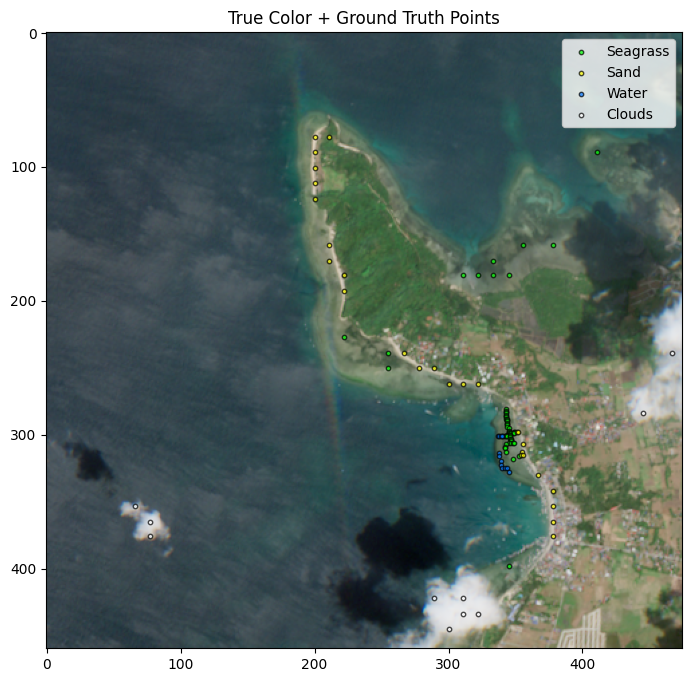

**End of Step 4 — Ground Truth Visualization**

In [35]:
# Display generated ground truth visualization
from IPython.display import display, Image, Markdown
img_gt = data_folder / 'ground_truth_visualization.png'
print('Ground truth visualization:')
if img_gt.exists():
    display(Image(str(img_gt)))
else:
    print('Not found:', img_gt)

display(Markdown('**End of Step 4 — Ground Truth Visualization**'))

## 5. Prepare, Split, and Balance Training Data

Flatten the feature stack, filter labeled pixels, split into train/validation/test sets, and balance the training set by oversampling.


In [36]:
print("Preparing and balancing data for 1D-CNN...")

features_all = band_matrix.reshape(rows * cols, num_bands)
labels_all = label_image.reshape(rows * cols, 1)

valid_mask = np.isin(labels_all.flatten(), np.arange(1, num_classes + 1))
valid_mask &= ~np.isnan(features_all).any(axis=1)

X = features_all[valid_mask]
Y = labels_all[valid_mask].flatten()

print(f"Valid labeled pixels: {len(X)}")

np.random.seed(0)
total_samples = len(X)
shuffled_idx = np.random.permutation(total_samples)

num_test = int(0.25 * total_samples)
num_val = int(0.10 * (total_samples - num_test))

idx_test = shuffled_idx[:num_test]
idx_val = shuffled_idx[num_test:num_test + num_val]
idx_train = shuffled_idx[num_test + num_val:]

X_test, Y_test = X[idx_test], Y[idx_test]
X_val, Y_val = X[idx_val], Y[idx_val]
X_train, Y_train = X[idx_train], Y[idx_train]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

X_train_bal = []
Y_train_bal = []

for c in range(1, num_classes + 1):
    class_mask = (Y_train == c)
    class_samples = X_train[class_mask]
    target_count = max(np.sum(Y_train == i) for i in range(1, num_classes + 1))

    X_train_bal.append(class_samples)
    Y_train_bal.extend([c] * len(class_samples))

    if len(class_samples) < target_count and len(class_samples) > 0:
        repeat_idx = np.random.choice(len(class_samples), target_count - len(class_samples), replace=True)
        X_train_bal.append(class_samples[repeat_idx])
        Y_train_bal.extend([c] * len(repeat_idx))

X_train_bal = np.vstack(X_train_bal)
Y_train_bal = np.array(Y_train_bal)

shuffle_idx = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
Y_train_bal = Y_train_bal[shuffle_idx]

print(f"Balanced train set: {len(X_train_bal)}")

Preparing and balancing data for 1D-CNN...
Valid labeled pixels: 109
Train: 74, Val: 8, Test: 27
Balanced train set: 176


## 6. Standardize Features and Convert to PyTorch Tensors

Fit the scaler, transform the held-out sets, store normalization values, and convert arrays into PyTorch tensors.


In [37]:
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train_bal)
X_val_z = scaler.transform(X_val)
X_test_z = scaler.transform(X_test)

mu = scaler.mean_.astype(np.float32)
sigma = scaler.scale_.astype(np.float32)

X_train_torch = torch.from_numpy(X_train_z.astype(np.float32))
Y_train_torch = torch.from_numpy((Y_train_bal - 1).astype(np.int64))
X_val_torch = torch.from_numpy(X_val_z.astype(np.float32))
Y_val_torch = torch.from_numpy((Y_val - 1).astype(np.int64))
X_test_torch = torch.from_numpy(X_test_z.astype(np.float32))
Y_test_torch = torch.from_numpy((Y_test - 1).astype(np.int64))

print("Step 6 Complete: Data prepared, balanced, and standardized.")

Step 6 Complete: Data prepared, balanced, and standardized.


## 7. Define the 1D-CNN Model

Implement the Coastal1DCNN architecture with convolution, batch normalization, pooling, dropout, and fully connected layers.


In [38]:
class Coastal1DCNN(nn.Module):
    def __init__(self, num_bands=16, num_classes=4):
        super().__init__()
        self.num_bands = num_bands

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4, 256)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.view(-1, 1, self.num_bands)
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu_fc1(self.fc1(x)))
        return self.fc_out(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Coastal1DCNN(num_bands=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

batch_size = 128
train_dataset = TensorDataset(X_train_torch, Y_train_torch)
val_dataset = TensorDataset(X_val_torch, Y_val_torch)
test_dataset = TensorDataset(X_test_torch, Y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Step 7 Complete: Model defined.")

Using device: cpu
Step 7 Complete: Model defined.


## 8. Train with Validation and Early Stopping

Configure the optimizer, loss function, and data loaders, then train across epochs while tracking losses, validation accuracy, and checkpoints.


In [39]:
num_epochs = 500
best_val_acc = 0
patience = 15
patience_counter = 0

print("\nTraining Neural Network...")
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += Y_batch.size(0)
            val_correct += (predicted == Y_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / max(val_total, 1)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_path = data_folder / 'best_model.pth'
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
model.load_state_dict(torch.load(best_model_path, map_location=device))


Training Neural Network...
Epoch [10/500] Train Loss: 0.4015, Val Loss: 0.7709, Val Acc: 75.00%
Epoch [20/500] Train Loss: 0.2094, Val Loss: 0.6779, Val Acc: 87.50%
Early stopping at epoch 26

Best validation accuracy: 87.50%


<All keys matched successfully>

## 9. Evaluate on the Test Set

Reload the best checkpoint, compute raw test accuracy, apply the sand-versus-cloud correction, and report adjusted accuracy.


In [40]:
print("Evaluating final model accuracy...")

model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_scores = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        test_total += Y_batch.size(0)
        test_correct += (predicted == Y_batch).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_scores.extend(probs.cpu().numpy())

raw_accuracy = 100 * test_correct / max(test_total, 1)
print(f"Raw Test Accuracy: {raw_accuracy:.2f}%")

all_preds = np.array(all_preds)
all_scores = np.array(all_scores)
cloud_idx = 3
sand_idx = 1
is_cloud = (all_preds == cloud_idx)
low_conf = all_scores[:, cloud_idx] < 0.5
sand_high = all_scores[:, sand_idx] > 0.5
flip_mask = is_cloud & low_conf & sand_high
all_preds[flip_mask] = sand_idx

Y_test_cpu = Y_test_torch.cpu().numpy()
adjusted_accuracy = 100 * np.sum(all_preds == Y_test_cpu) / max(len(Y_test_cpu), 1)
print(f"Adjusted Test Accuracy (Sand/Cloud rule): {adjusted_accuracy:.2f}%")

Evaluating final model accuracy...
Raw Test Accuracy: 85.19%
Adjusted Test Accuracy (Sand/Cloud rule): 85.19%


## 10. Run Full-Image Prediction and Post-Processing

Predict the unlabeled pixels across the full scene, preserve ground truth labels, and apply the rule-based cleanup logic.


In [41]:
print("Classifying all pixels across the map...")

labels_all_flat = label_image.reshape(rows * cols)
unknown_mask_all = (labels_all_flat == 0)
X_unknown = features_all[unknown_mask_all]

if len(X_unknown) > 0:
    X_unknown_z = scaler.transform(X_unknown)
    X_unknown_torch = torch.from_numpy(X_unknown_z.astype(np.float32)).to(device)

    model.eval()
    with torch.no_grad():
        unknown_outputs = model(X_unknown_torch)
        unknown_probs = torch.softmax(unknown_outputs, dim=1)
        _, unknown_preds = torch.max(unknown_outputs.data, 1)

    unknown_preds = unknown_preds.cpu().numpy() + 1
    unknown_scores = unknown_probs.cpu().numpy()

    is_cloud_u = (unknown_preds == 4)
    low_conf_u = unknown_scores[:, 3] < 0.5
    sand_high_u = unknown_scores[:, 1] > 0.5
    flip_mask_u = is_cloud_u & low_conf_u & sand_high_u
    unknown_preds[flip_mask_u] = 2

    new_labels = labels_all_flat.copy()
    new_labels[unknown_mask_all] = unknown_preds
else:
    new_labels = labels_all_flat.copy()

new_labels[labels_all_flat != 0] = labels_all_flat[labels_all_flat != 0]
classified_image = new_labels.reshape(rows, cols)
classified_clean = classified_image.copy()
unlabeled_mask_image = (labels_all_flat.reshape(rows, cols) == 0)

inland_mask = (NDWI < -0.05) & ~water_mask & unlabeled_mask_image
classified_clean[inland_mask & (classified_clean == 2)] = 0

water_strong_mask = water_mask & (NDWI > 0) & unlabeled_mask_image
classified_clean[water_strong_mask & (classified_clean == 2)] = 3

kernel = np.ones((11, 11))
coastal_buffer_mask = signal.convolve2d(water_mask.astype(float), kernel, mode='same') > 0
inland_far_mask = ~coastal_buffer_mask & unlabeled_mask_image
classified_clean[inland_far_mask & ((classified_clean == 2) | (classified_clean == 3))] = 0

classified_image = classified_clean
print("Classification complete.")

Classifying all pixels across the map...
Classification complete.


## 11. Save Model Artifacts and Parameters

Export the normalization statistics, band metadata, and trained PyTorch weights for later inference.


In [42]:
model_save_file = data_folder / 'Coastal_Area_Classifier.mat'
save_dict = {
    'mu': mu,
    'sigma': sigma,
    'numBands': np.array([num_bands]),
    'numClasses': np.array([num_classes]),
    'classNames': np.array(class_names, dtype=object),
}
sio.savemat(model_save_file, save_dict, do_compression=True)
print(f"Model parameters saved to: {model_save_file}")

torch_model_file = data_folder / 'coastal_classifier_pytorch.pth'
torch.save(model.state_dict(), torch_model_file)
print(f"PyTorch model saved to: {torch_model_file}")

Model parameters saved to: C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN\trained_model\Coastal_Area_NRG\Coastal_Area_Classifier.mat
PyTorch model saved to: C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN\trained_model\Coastal_Area_NRG\coastal_classifier_pytorch.pth


## 12. Visualize Classification Overlay and Training History

Create the overlay on the true-color image and plot the training/validation loss and accuracy curves.


In [43]:
if tci_image is not None:
    from PIL import Image as PILImage

    rgb_base = tci_image.astype(np.float32) / 255.0 if tci_image.max() > 1 else tci_image.astype(np.float32)

    overlay_r = np.zeros((rows, cols))
    overlay_g = np.zeros((rows, cols))
    overlay_b = np.zeros((rows, cols))

    coastal_mask = ~land_mask

    overlay_g[classified_image == 1] = 1
    overlay_r[classified_image == 2] = 1
    overlay_g[classified_image == 2] = 1
    overlay_b[classified_image == 3] = 1
    overlay_r[classified_image == 4] = 1
    overlay_g[classified_image == 4] = 1
    overlay_b[classified_image == 4] = 1

    overlay = np.stack([overlay_r, overlay_g, overlay_b], axis=2)
    alpha = 0.5
    blend = rgb_base.copy()
    mask = np.any(overlay > 0, axis=2)

    for c in range(3):
        ch_base = blend[:, :, c]
        ch_ov = overlay[:, :, c]
        ch_base[mask] = (1 - alpha) * ch_base[mask] + alpha * ch_ov[mask]
        blend[:, :, c] = ch_base

    blend_uint8 = (blend * 255).astype(np.uint8)
    blend_image = PILImage.fromarray(blend_uint8)
    blend_path = data_folder / 'classified_overlay_python.png'
    blend_image.save(blend_path)
    print(f"Classified overlay saved to: {blend_path}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(tci_image)
    axes[0].set_title('Original True Color')
    axes[0].axis('off')

    axes[1].imshow(blend_uint8)
    axes[1].set_title('Classification Overlay\n(Green=Seagrass, Yellow=Sand, Blue=Water, White=Clouds)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(data_folder / 'classification_comparison.png', dpi=100, bbox_inches='tight')
    plt.close()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_accs)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Over Time')
plt.grid()

plt.tight_layout()
plt.savefig(data_folder / 'training_history.png', dpi=100, bbox_inches='tight')
plt.close()


Classified overlay saved to: C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN\trained_model\Coastal_Area_NRG\classified_overlay_python.png


### Classified overlay

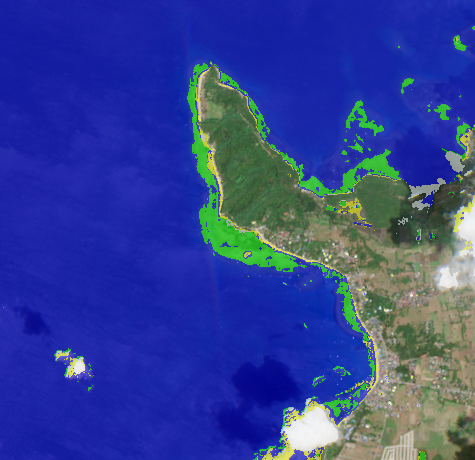

### Classification comparison

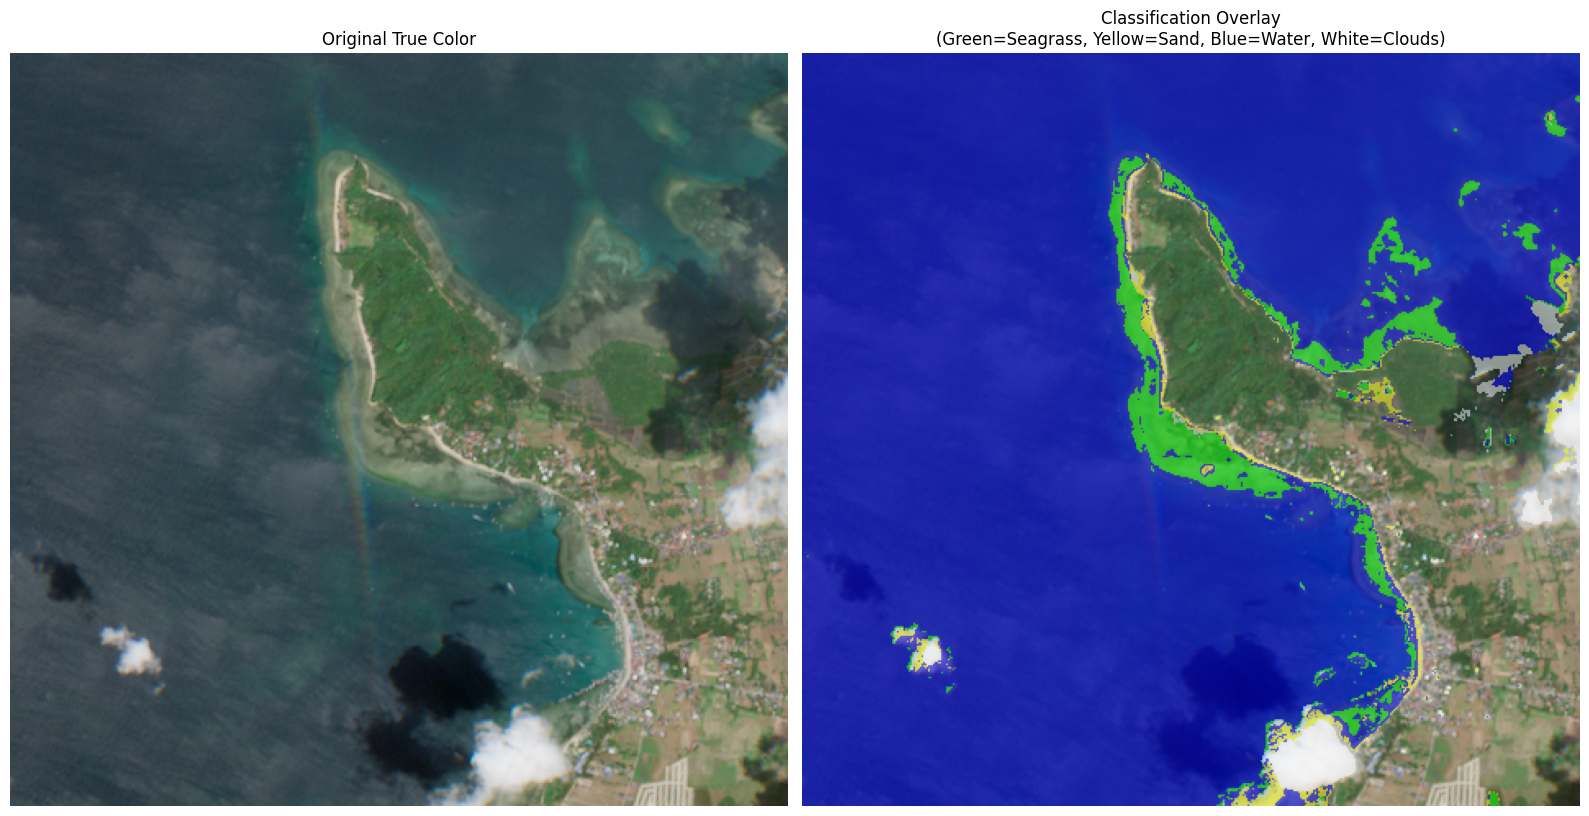

### Training history

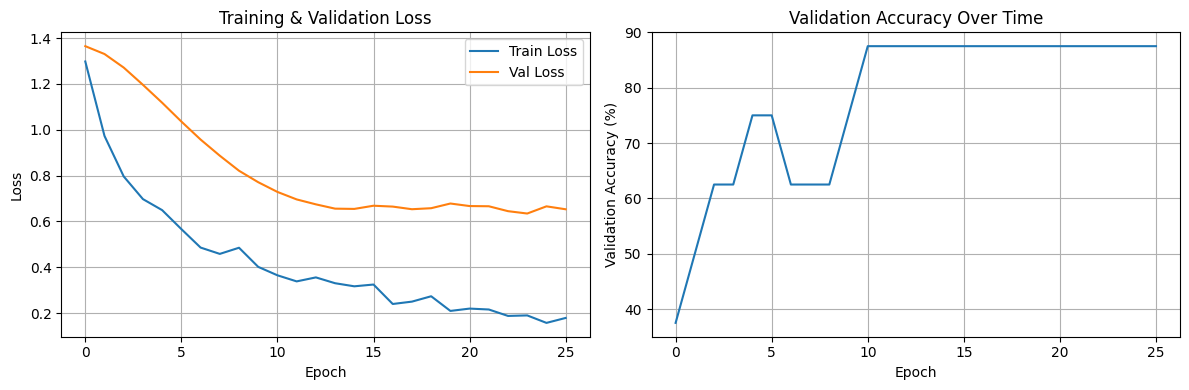


End of visualization outputs (steps 11-12).


In [44]:
# Display classification outputs and training history
from IPython.display import display, Image, Markdown

imgs = [
    ('Classified overlay', data_folder / 'classified_overlay_python.png'),
    ('Classification comparison', data_folder / 'classification_comparison.png'),
    ('Training history', data_folder / 'training_history.png')
]

for title, p in imgs:
    display(Markdown(f'### {title}'))
    if p.exists():
        display(Image(str(p)))
    else:
        print('Not found:', p)

print('\nEnd of visualization outputs (steps 11-12).')

## 13. Export Metrics and Summary Files

Count coastal pixels by class, write metrics to CSV with a timestamp, and store the final summary outputs in the project folder.


In [45]:
coastal_pixels = ~land_mask

total_coastal_pixels = np.sum(coastal_pixels)
seagrass_count = np.sum((classified_image == 1) & coastal_pixels)
sand_count = np.sum((classified_image == 2) & coastal_pixels)

print("\nCoastal pixel counts:")
print(f"  Total coastal pixels: {total_coastal_pixels}")
print(f"  Seagrass pixels: {seagrass_count}")
print(f"  Sand pixels: {sand_count}")

metrics_df = pd.DataFrame({
    'TotalCoastalPixels': [total_coastal_pixels],
    'SeagrassPixels': [seagrass_count],
    'SandPixels': [sand_count],
    'RawTestAccuracy': [raw_accuracy],
    'AdjustedTestAccuracy': [adjusted_accuracy],
})

timestamp_str = datetime.now().strftime('%Y-%m-%d_%H%M%S')
metrics_file = data_folder / f'coastal_metrics_{timestamp_str}.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f"Metrics exported to: {metrics_file}")

print("\nTraining complete!")
print("Model saved and ready for inference.")


Coastal pixel counts:
  Total coastal pixels: 169700
  Seagrass pixels: 8045
  Sand pixels: 2008
Metrics exported to: C:\Users\James\OneDrive\Documents\James\BSU\3202\Software Design\SEASCAN\trained_model\Coastal_Area_NRG\coastal_metrics_2026-05-18_230128.csv

Training complete!
Model saved and ready for inference.
